In [6]:
"""

Solow-Swann Model / Modelo Solow-Swann

Author / Autor: imoripaolo

"""

import numpy as np
import matplotlib.pyplot as plt

size = 100

n, delta, alpha, s, g = 0.2, 0.1, 0.3, 0.5, 0.4 

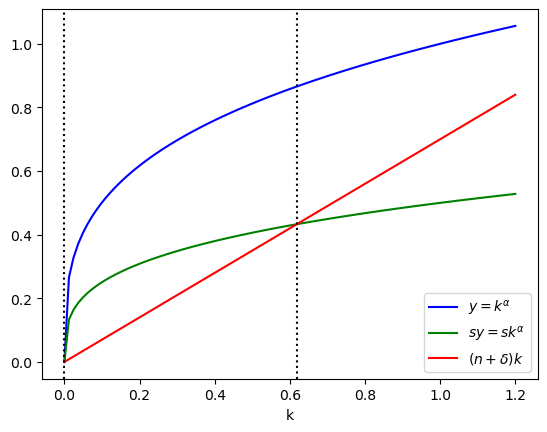

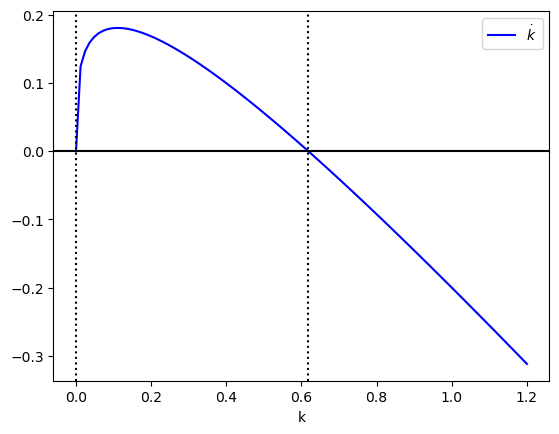

$k^{ss}$= 0.6181818181818182 e $y^{ss}$= 0.8656351204459324


In [7]:
"""

Capital per Labor / Capital por Trabalhador

Version with g = 0 / Versão com g = 0

y = k**alpha
k_dot = sy - (n + delta) k = sk**alpha - (n + delta) k

"""

k = np.linspace(0,1.2, size)
y = np.zeros(size)
i = np.zeros(size)
dep = np.zeros(size)
k_dot = np.zeros(size)

for j in range(0,size):
    y[j] = k[j]**alpha
    i[j] = s*(k[j]**alpha)
    dep[j] = (n + delta + g)*k[j]
    k_dot[j] = i[j] - dep[j]

ss = np.argmin(k_dot[1:size]**2)
steady = (k[ss+1], k[ss+1]**alpha)

fig, ax = plt.subplots()
ax.plot(k, y,'b', label=r'$y=k^\alpha$')
ax.plot(k, i,'g', label=r'$sy=sk^\alpha$')
ax.plot(k, dep,'r', label=r'$(n+\delta)k$')
plt.axvline(x=steady[0], color='black', linestyle = 'dotted')
plt.axvline(x=0, color='black', linestyle = 'dotted')
ax.set_ylabel('')
ax.set_xlabel('k')
plt.legend()
plt.show()


fig, ax = plt.subplots()
ax.plot(k, k_dot,'b', label=r'$\dot{k}$')
plt.axvline(x=steady[0], color='black', linestyle = 'dotted')
plt.axvline(x=0, color='black', linestyle = 'dotted')
plt.axhline(y=0, color='black')
ax.set_ylabel('')
ax.set_xlabel('k')
plt.legend()
plt.show()

print(r'$k^{ss}$=', steady[0], "e $y^{ss}$=", steady[1] )

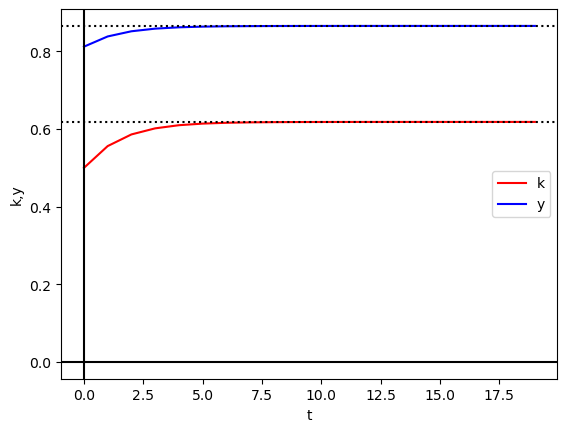

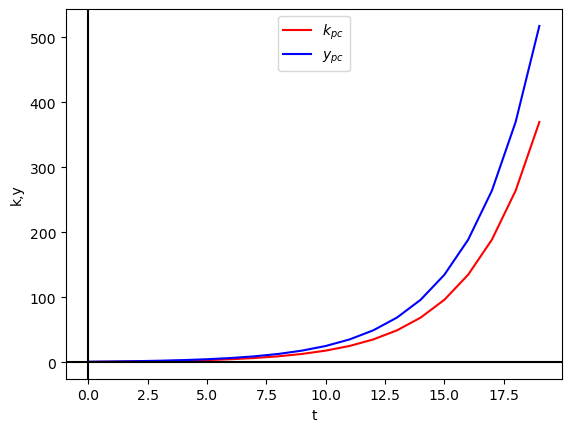

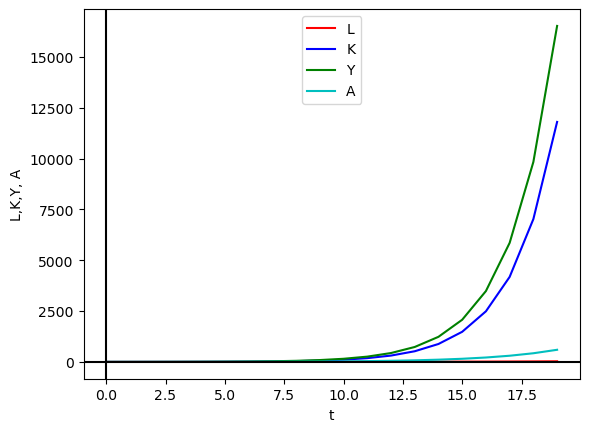

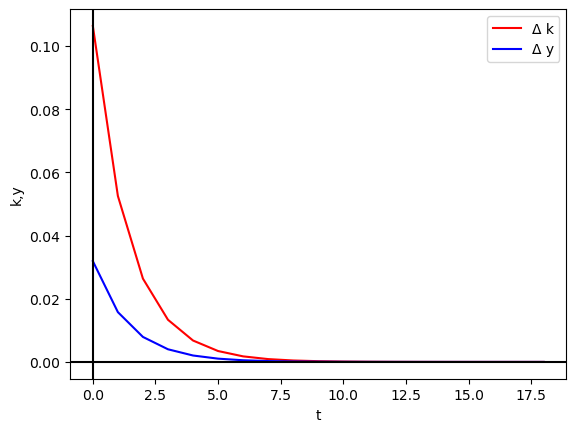

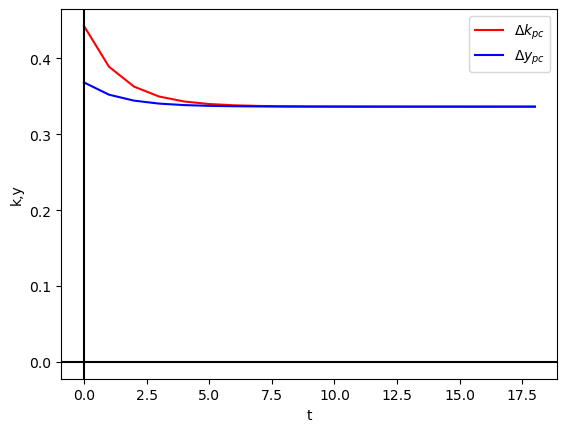

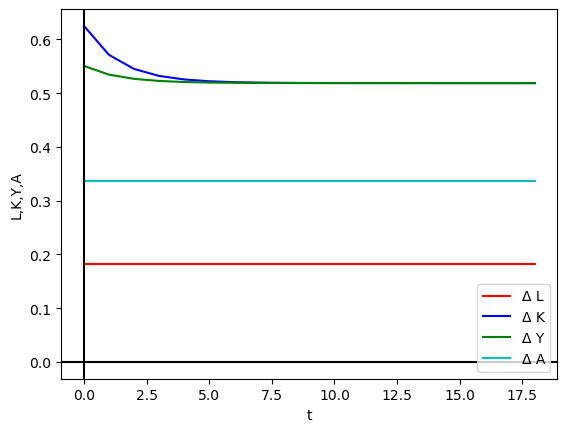

In [19]:
"""

Variable Dynamics / Dinâmica das Variáveis

"""

A, L, k, y, k_pc, y_pc, K, Y = np.zeros(20), np.zeros(20), np.zeros(20), np.zeros(20), np.zeros(20), np.zeros(20), np.zeros(20), np.zeros(20)
dA, dL, dk, dy, dk_pc, dy_pc, dK, dY = np.zeros(19), np.zeros(19), np.zeros(19), np.zeros(19), np.zeros(19), np.zeros(19), np.zeros(19), np.zeros(19)
A[0], L[0], k[0] = 1, 1, 0.5
y[0] =  k[0]**alpha
k_pc[0], y_pc[0] = A[0]*k[0], A[0]*y[0]
K[0], Y[0] = k_pc[0]*L[0], y_pc[0]*L[0]

for t in range(1,20):
    A[t] = A[t-1]*(1+g) 
    L[t] = L[t-1]*(1+n) 
    k[t] = k[t-1] + s*(k[t-1]**alpha) - (n+delta+g)*k[t-1]
    y[t] = k[t]**alpha
    k_pc[t] = A[t]*k[t]
    y_pc[t] = A[t]*y[t]
    K[t] = A[t]*k[t]*L[t]
    Y[t] = A[t]*y[t]*L[t]

for t in range(0,19):
    dA[t] = np.log(A[t+1]) - np.log(A[t])
    dL[t] = np.log(L[t+1]) - np.log(L[t])
    dk[t] = np.log(k[t+1]) - np.log(k[t])
    dy[t] = np.log(y[t+1]) - np.log(y[t])
    dk_pc[t] = np.log(k_pc[t+1]) - np.log(k_pc[t])
    dy_pc[t] = np.log(y_pc[t+1]) - np.log(y_pc[t])    
    dK[t] = np.log(K[t+1]) - np.log(K[t])
    dY[t] = np.log(Y[t+1]) - np.log(Y[t])

fig, ax = plt.subplots()
ax.plot(k,'r', label = 'k' )
ax.plot(y,'b', label = 'y' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
plt.axhline(y=steady[0], color='black', linestyle = 'dotted')
plt.axhline(y=steady[1], color='black', linestyle = 'dotted')
ax.set_ylabel('k,y')
ax.set_xlabel('t')
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(k_pc,'r', label = r'$k_{pc}$' )
ax.plot(y_pc,'b', label = r'$y_{pc}$' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
ax.set_ylabel('k,y')
ax.set_xlabel('t')
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(L,'r', label = 'L' )
ax.plot(K,'b', label = 'K' )
ax.plot(Y,'g', label = 'Y' )
ax.plot(A,'c', label = 'A' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
ax.set_ylabel('L,K,Y, A')
ax.set_xlabel('t')
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(dk,'r', label = '\u0394 k' )
ax.plot(dy,'b', label = '\u0394 y' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
ax.set_ylabel('k,y')
ax.set_xlabel('t')
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(dk_pc,'r', label = '\u0394' r'$k_{pc}$' )
ax.plot(dy_pc,'b', label = '\u0394' r'$y_{pc}$' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
ax.set_ylabel('k,y')
ax.set_xlabel('t')
plt.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(dL,'r', label = '\u0394 L' )
ax.plot(dK,'b', label = '\u0394 K' )
ax.plot(dY,'g', label = '\u0394 Y' )
ax.plot(dA,'c', label = '\u0394 A' )
plt.axvline(x=0, color='black')
plt.axhline(y=0, color='black')
ax.set_ylabel('L,K,Y,A')
ax.set_xlabel('t')
plt.legend()
plt.show()